# 摩斯电码呼吸传感器数据分类 (Deep Learning for Breath Sensor Morse Code)

本 Notebook 构建了一个深度学习模型，用于处理呼吸传感器采集的摩斯电码数据。Data 文件夹下的 CSV 文件包含了 A-Z 的摩斯电码呼吸波形数据。

流程如下：
1.  **环境准备**：导入 PyTorch, Pandas, Numpy 等库。
2.  **数据加载与探索**：读取 CSV，解析文件名获取标签，检查数据维度。
3.  **数据预处理**：处理缺失值，截断/填充序列至固定长度，标准化。
4.  **数据集构建**：创建 PyTorch Dataset 和 DataLoader。
5.  **模型构建**：设计 1D-CNN 或 LSTM 模型。
6.  **模型训练**：训练模型并监控 Loss/Acc。
7.  **评估与可视化**：查看验证集准确率及混淆矩阵。

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Switched back to Deep Learning approach with the new split dataset.")

Using device: cuda
Switched back to Deep Learning approach with the new split dataset.


In [17]:
# 2. 加载新拆分的数据集

DATA_DIR = r"d:\huxi\split_dataset"

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR}. Please run the split script first.")

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"Total split samples found: {len(all_files)}")

labels = []
file_paths = []

for filename in all_files:
    # 新文件名格式: A_AB_A_10_3_sample1.csv
    # 第一个部分即为标签
    parts = filename.split('_')
    label = parts[0]
    
    # 简单的验证标签是否为单个字母 (A-Z)
    if len(label) == 1 and label.isalpha():
        labels.append(label)
        file_paths.append(os.path.join(DATA_DIR, filename))

df = pd.DataFrame({'file_path': file_paths, 'label': labels})

print(f"Valid samples parsed: {len(df)}")
print("\nSample distribution per class:")
print(df['label'].value_counts().sort_index())

# Label Encoding
label_encoder = LabelEncoder()
df['label_idx'] = label_encoder.fit_transform(df['label'])
NUM_CLASSES = len(label_encoder.classes_)
print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Classes: {label_encoder.classes_}")

Total split samples found: 1281
Valid samples parsed: 1281

Sample distribution per class:
label
A    50
B    50
C    50
D    50
E    50
F    50
G    50
H    50
I    50
J    50
K    50
L    50
M    50
N    50
O    50
P    50
Q    50
R    50
S    31
T    50
U    50
V    50
W    50
X    50
Y    50
Z    50
Name: count, dtype: int64

Number of classes: 26
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


Sample data shape: (306, 2)


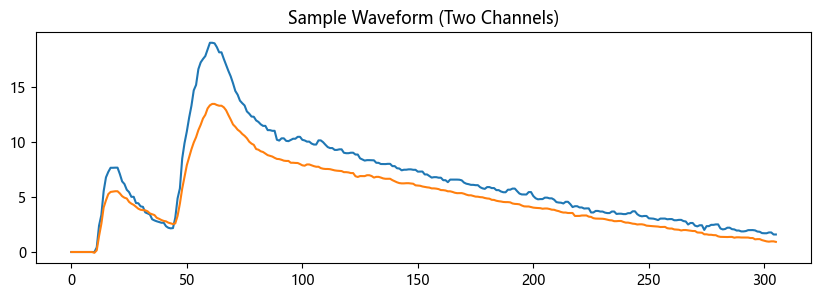

In [18]:
def read_sample_csv(file_path):
    """
    读取拆分后的样本 CSV 文件。
    拆分后的文件第一行就是列名 (header=0)。
    """
    try:
        # 新数据集是标准的 CSV，第一行作为 header
        # 列名应包含: "Time (s)", "R (kohm)", "ΔR/R0 (%)" 等
        data = pd.read_csv(file_path)
        
        # 寻找包含 ΔR/R0 的列
        # 注意：拆分脚本保留了原始列名，可能会有 "ΔR/R0 (%)" 和 "ΔR/R0 (%).1"
        # 假设我们依然取第 2 列和第 4 列的数据特征 (Ch1 和 Ch2)
        # 0:Time, 1:R1, 2:D1, 3:R2, 4:D2
        
        # 为了稳健，我们通过列名关键字查找
        delta_cols = [c for c in data.columns if 'ΔR/R0' in str(c)]
        
        if len(delta_cols) >= 2:
            # 取前两个 ΔR/R0 列 (对应 Ch1, Ch2)
            features = data[delta_cols[:2]].copy()
        else:
            # 只有1列或者找不到，回退到按位置取 (2, 4)
            # 确保不越界
            if data.shape[1] > 4:
                features = data.iloc[:, [2, 4]].copy()
            else:
                 # 实在没办法，取所有数值列
                features = data.select_dtypes(include=[np.number])

        # 转为数值，处理 NaNs
        features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
        
        return features.values
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

# 检查一个样本
sample_data = read_sample_csv(df['file_path'].iloc[0])
print(f"Sample data shape: {sample_data.shape}")
plt.figure(figsize=(10, 3))
plt.plot(sample_data)
plt.title("Sample Waveform (Two Channels)")
plt.show()

In [19]:
# 3. 数据集定义 (Dataset & DataLoader)

# 统计一下样本长度
lengths = []
for p in df['file_path']:
    d = read_sample_csv(p)
    if d is not None:
        lengths.append(len(d))
        
print(f"Max Len: {np.max(lengths)}, Min Len: {np.min(lengths)}, Median: {np.median(lengths)}")

# 大部分应该是 30秒 * 采样率
# 设定一个固定的输入长度，可以覆盖绝大多数
SEQUENCE_LENGTH = int(np.percentile(lengths, 95)) 
print(f"Setting SEQUENCE_LENGTH to {SEQUENCE_LENGTH}")

class MorseDataset(Dataset):
    def __init__(self, dataframe, seq_len, transform=None):
        self.df = dataframe
        self.seq_len = seq_len
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = read_sample_csv(row['file_path'])
        label = row['label_idx']
        
        if data is None:
            data = np.zeros((self.seq_len, 2))
            
        L, C = data.shape
        
        # 长度标准化
        if L >= self.seq_len:
            data = data[:self.seq_len, :]
        else:
            pad = np.zeros((self.seq_len - L, C))
            data = np.vstack((data, pad))
            
        # Z-Score Standardization PER SAMPLE
        # 对波形数据，通常对每条样本独立做归一化是比较好的，消除幅度差异
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0) + 1e-6
        data = (data - mean) / std
        
        # [Length, Channel] -> [Channel, Length]
        data = torch.tensor(data, dtype=torch.float32).permute(1, 0)
        
        return data, torch.tensor(label, dtype=torch.long)

# 均衡划分 Train/Val (Balanced Split)
# 用户要求：验证集中每个类别的样本数量一致，作为混淆矩阵测试的标准。
min_count = df['label_idx'].value_counts().min()
# 设置验证集每个类别的样本数，例如取最小类别的 20% (至少 2 个)
val_count_per_class = max(2, int(min_count * 0.2))
print(f"Balanced Validation: Selecting {val_count_per_class} samples per class.")

val_indices = []
# Group by label and sample
for label_val in df['label_idx'].unique():
    indices = df[df['label_idx'] == label_val].index.values
    if len(indices) >= val_count_per_class:
        # 无放回抽样
        chosen = np.random.choice(indices, val_count_per_class, replace=False)
        val_indices.extend(chosen)
    else:
        val_indices.extend(indices)

val_indices = np.array(val_indices)
train_indices = df.index.difference(val_indices)

train_df = df.loc[train_indices].reset_index(drop=True)
val_df = df.loc[val_indices].reset_index(drop=True)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)} (Balanced)")

train_dataset = MorseDataset(train_df, seq_len=SEQUENCE_LENGTH)
val_dataset = MorseDataset(val_df, seq_len=SEQUENCE_LENGTH)

# 使用 WeightedRandomSampler 处理类别不平衡 (主要针对训练集，验证集已经是均衡的了)
class_counts = train_df['label_idx'].value_counts().sort_index().values
class_weights = 1. / class_counts
# map label to weight
sample_weights = [class_weights[label] for label in train_df['label_idx']]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 64

# Train loader uses Sampler for balancing
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
# Val loader just shuffles False
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Max Len: 308, Min Len: 286, Median: 305.0
Setting SEQUENCE_LENGTH to 307
Balanced Validation: Selecting 6 samples per class.
Train size: 1125, Val size: 156 (Balanced)
Train batches: 18, Val batches: 3


In [20]:
# 4. 构建模型 (1D-CNN + LSTM Attention)
# 数据变多后，我们可以使用稍微深一点的模型，并加入 Dropout 防止过拟合

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, padding=2):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.downsample = None
            
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        return out

class DeepMorseNet(nn.Module):
    def __init__(self, num_classes=26, input_channels=2):
        super(DeepMorseNet, self).__init__()
        
        # 1. CNN Features Extraction (ResNet-style blocks)
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            ResidualBlock(32, 64),
            nn.MaxPool1d(2),
            
            ResidualBlock(64, 128),
            nn.MaxPool1d(2),
            
            ResidualBlock(128, 256),
            nn.AdaptiveAvgPool1d(40) # 强制压缩到长度40的时间步，减少LSTM计算量
        )
        
        # 2. Bi-LSTM
        self.lstm = nn.LSTM(input_size=256, hidden_size=128, num_layers=2, 
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        # 3. Classifier
        self.fc = nn.Sequential(
            nn.Linear(128*2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x: [Batch, 2, SeqLen]
        features = self.cnn(x) # -> [Batch, 256, 40]
        
        features = features.permute(0, 2, 1) # -> [Batch, 40, 256]
        
        lstm_out, _ = self.lstm(features) # -> [Batch, 40, 256]
        
        # Use last time step output (or max-pooling over time)
        # Using Max Pooling over time captures the most salient features
        context = torch.max(lstm_out, dim=1)[0] # -> [Batch, 256]
        
        out = self.fc(context)
        return out

model = DeepMorseNet(num_classes=NUM_CLASSES).to(device)
print(model)
# Test Input
dum = torch.randn(2, 2, SEQUENCE_LENGTH).to(device)
print(f"Output Head: {model(dum).shape}")

DeepMorseNet(
  (cnn): Sequential(
    (0): Conv1d(2, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ResidualBlock(
      (conv1): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
    )
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): ResidualBlock(
      (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, tra

Starting training...
Epoch 1/100 | Train Loss: 3.2012 Acc: 0.0871 | Val Loss: 3.2077 Acc: 0.0513
Epoch 2/100 | Train Loss: 2.8055 Acc: 0.1973 | Val Loss: 2.5116 Acc: 0.2051
Epoch 3/100 | Train Loss: 2.3611 Acc: 0.2667 | Val Loss: 2.0636 Acc: 0.3205
Epoch 4/100 | Train Loss: 1.9141 Acc: 0.3858 | Val Loss: 1.7730 Acc: 0.3718
Epoch 5/100 | Train Loss: 1.6577 Acc: 0.4293 | Val Loss: 1.5974 Acc: 0.4423
Epoch 6/100 | Train Loss: 1.3811 Acc: 0.5298 | Val Loss: 1.3977 Acc: 0.5064
Epoch 7/100 | Train Loss: 1.1755 Acc: 0.6000 | Val Loss: 1.4049 Acc: 0.5385
Epoch 8/100 | Train Loss: 0.9879 Acc: 0.6364 | Val Loss: 1.2400 Acc: 0.6282
Epoch 9/100 | Train Loss: 0.9649 Acc: 0.6684 | Val Loss: 0.9914 Acc: 0.6667
Epoch 10/100 | Train Loss: 0.8159 Acc: 0.7324 | Val Loss: 1.2426 Acc: 0.5962
Epoch 11/100 | Train Loss: 0.7076 Acc: 0.7618 | Val Loss: 0.7141 Acc: 0.7179
Epoch 12/100 | Train Loss: 0.5822 Acc: 0.8062 | Val Loss: 0.7770 Acc: 0.7564
Epoch 13/100 | Train Loss: 0.5025 Acc: 0.8249 | Val Loss: 0.7900

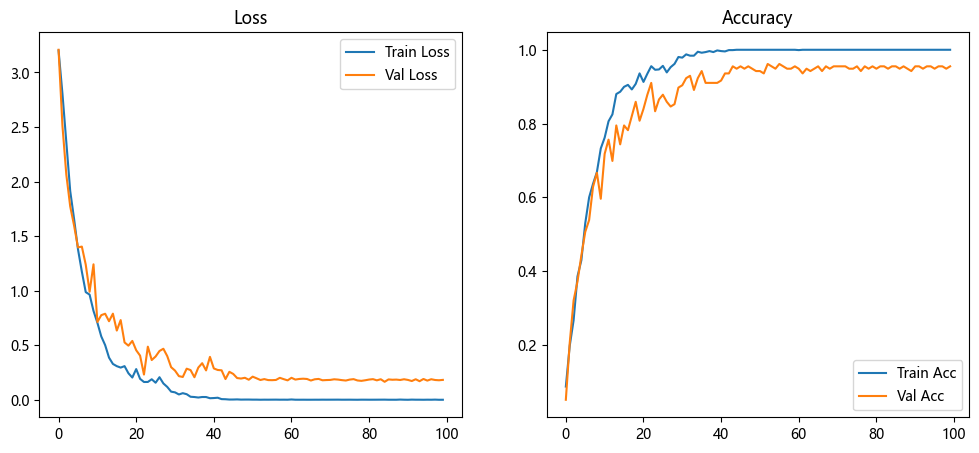

In [21]:
# 5. 训练 Loop

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

EPOCHS = 100
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 梯度裁剪防止梯度爆炸
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += inputs.size(0)
        
    train_loss = running_loss / total
    train_acc = correct.double() / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            val_total += inputs.size(0)
            
    val_loss = val_loss / val_total
    val_acc = val_correct.double() / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())
    
    # Scheduler step
    scheduler.step(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_deep_morse_model.pth')
        # print("  Saved Best Model")

print(f"Training Complete. Best Val Acc: {best_val_acc:.4f}")

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

Loaded best model.
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         6
           B       1.00      1.00      1.00         6
           C       1.00      0.83      0.91         6
           D       1.00      1.00      1.00         6
           E       1.00      1.00      1.00         6
           F       0.86      1.00      0.92         6
           G       1.00      1.00      1.00         6
           H       1.00      0.83      0.91         6
           I       1.00      0.83      0.91         6
           J       1.00      1.00      1.00         6
           K       1.00      1.00      1.00         6
           L       1.00      1.00      1.00         6
           M       0.86      1.00      0.92         6
           N       1.00      0.83      0.91         6
           O       1.00      1.00      1.00         6
           P       1.00      1.00      1.00         6
           Q       1.00      1.00      1.00         6
        

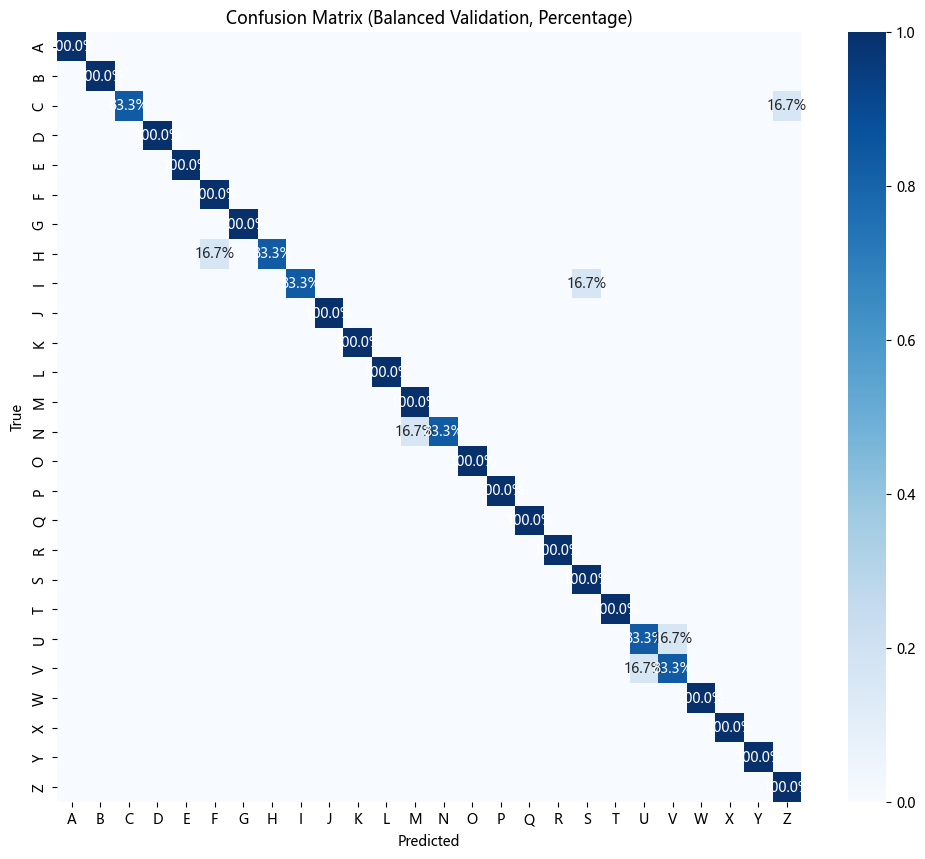

In [22]:
# 6. Final Evaluation
if os.path.exists('best_deep_morse_model.pth'):
    model.load_state_dict(torch.load('best_deep_morse_model.pth'))
    # model.load_state_dict(torch.load('best_deep_morse_model.pth', map_location=device)) # 如果设备不一致
    print("Loaded best model.")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

# 制作自定义注解：0不显示%，非0显示百分比
cm = confusion_matrix(all_labels, all_preds, normalize='true')

annot_mat = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        if val == 0:
            annot_mat[i, j] = "" # 0 不显示
        else:
            annot_mat[i, j] = "{:.1%}".format(val) # 显示百分比

plt.figure(figsize=(12, 10))
# fmt='' because text comes from annot array
sns.heatmap(cm, annot=annot_mat, fmt='', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Balanced Validation, Percentage)')
plt.show()

# 8. 单通道效果对比实验 (Channel Comparison)
为了探究不同传感器通道（Channel 1 vs Channel 2）对识别准确率的贡献，我们分别单独使用每个通道的数据进行模型训练与评估。

In [23]:
# 定义支持通道选择的数据集类
class MorseChannelDataset(Dataset):
    def __init__(self, dataframe, seq_len, channel_indices=[0]):
        self.df = dataframe
        self.seq_len = seq_len
        self.channel_indices = channel_indices # [0] for Ch1, [1] for Ch2
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = read_sample_csv(row['file_path'])
        label = row['label_idx']
        
        if data is None:
            data = np.zeros((self.seq_len, 2))
            
        L, C = data.shape
        # Pad/Cut
        if L >= self.seq_len:
            data = data[:self.seq_len, :]
        else:
            pad = np.zeros((self.seq_len - L, C))
            data = np.vstack((data, pad))
            
        # Select specific channels
        # data shape (Seq, 2) -> select columns
        data = data[:, self.channel_indices]
        
        # Normalize (Standardize)
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0) + 1e-6
        data = (data - mean) / std
        
        # Flatten constraints for 1D input if needed, but for Conv1D we need (Channels, Length)
        # Handle case where selection results in vectors instead of matrices
        if data.ndim == 1:
            data = data.reshape(-1, 1) # (Seq, 1)
            
        # Permute to (Channels, Length)
        data = torch.tensor(data, dtype=torch.float32).permute(1, 0)
        
        return data, torch.tensor(label, dtype=torch.long)

def train_channel_experiment(channel_indices, name, save_name, epochs=30):
    print(f"\n=== Starting Experiment: {name} ===")
    
    # 1. Datasets & Loaders
    train_ds = MorseChannelDataset(train_df, seq_len=SEQUENCE_LENGTH, channel_indices=channel_indices)
    val_ds = MorseChannelDataset(val_df, seq_len=SEQUENCE_LENGTH, channel_indices=channel_indices)
    
    # Re-calculate sampler for new dataset instance
    class_counts = train_df['label_idx'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = [class_weights[label] for label in train_df['label_idx']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    t_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    v_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # 2. Model
    # Input channels = len(channel_indices)
    model_exp = DeepMorseNet(num_classes=NUM_CLASSES, input_channels=len(channel_indices)).to(device)
    
    # 3. Optimizer
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model_exp.parameters(), lr=0.001, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3, verbose=True)
    
    # 4. Loop
    history_exp = {'val_acc': [], 'train_acc': [], 'val_loss': []}
    best_acc = 0.0
    
    for ep in range(epochs):
        model_exp.train()
        correct = 0; total = 0
        for inp, lbl in t_loader:
            inp, lbl = inp.to(device), lbl.to(device)
            opt.zero_grad()
            out = model_exp(inp)
            loss = crit(out, lbl)
            loss.backward()
            nn.utils.clip_grad_norm_(model_exp.parameters(), 1.0)
            opt.step()
            
            _, p = torch.max(out, 1)
            correct += (p == lbl).sum().item()
            total += lbl.size(0)
        
        t_acc = correct / total
        
        # Validation
        model_exp.eval()
        v_correct = 0; v_total = 0; v_loss = 0
        with torch.no_grad():
            for inp, lbl in v_loader:
                inp, lbl = inp.to(device), lbl.to(device)
                out = model_exp(inp)
                l = crit(out, lbl)
                v_loss += l.item() * inp.size(0)
                _, p = torch.max(out, 1)
                v_correct += (p == lbl).sum().item()
                v_total += lbl.size(0)
        
        v_acc = v_correct / v_total
        v_loss = v_loss / v_total
        
        history_exp['val_acc'].append(v_acc)
        history_exp['train_acc'].append(t_acc)
        history_exp['val_loss'].append(v_loss)
        
        sched.step(v_acc)
        
        if (ep+1) % 5 == 0:
            print(f"[{name}] Ep {ep+1}/{epochs}: Train Acc={t_acc:.3f}, Val Acc={v_acc:.3f}")
        
        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model_exp.state_dict(), save_name)
            
    print(f"Finished {name}. Best Val Acc: {best_acc:.4f}. Model saved to {save_name}")
    return history_exp

# 运行实验
# Channel 1 only (Index 0)
hist_ch1 = train_channel_experiment([0], "Only Channel 1", "best_model_ch1.pth", epochs=100)

# Channel 2 only (Index 1)
hist_ch2 = train_channel_experiment([1], "Only Channel 2", "best_model_ch2.pth", epochs=100)


=== Starting Experiment: Only Channel 1 ===
[Only Channel 1] Ep 5/100: Train Acc=0.462, Val Acc=0.449
[Only Channel 1] Ep 10/100: Train Acc=0.792, Val Acc=0.846
[Only Channel 1] Ep 15/100: Train Acc=0.894, Val Acc=0.885
[Only Channel 1] Ep 20/100: Train Acc=0.944, Val Acc=0.833
Epoch 00023: reducing learning rate of group 0 to 5.0000e-04.
[Only Channel 1] Ep 25/100: Train Acc=0.972, Val Acc=0.917
[Only Channel 1] Ep 30/100: Train Acc=0.990, Val Acc=0.955
Epoch 00034: reducing learning rate of group 0 to 2.5000e-04.
[Only Channel 1] Ep 35/100: Train Acc=0.989, Val Acc=0.929
[Only Channel 1] Ep 40/100: Train Acc=1.000, Val Acc=0.949
Epoch 00041: reducing learning rate of group 0 to 1.2500e-04.
Epoch 00045: reducing learning rate of group 0 to 6.2500e-05.
[Only Channel 1] Ep 45/100: Train Acc=0.998, Val Acc=0.942
Epoch 00049: reducing learning rate of group 0 to 3.1250e-05.
[Only Channel 1] Ep 50/100: Train Acc=1.000, Val Acc=0.955
Epoch 00053: reducing learning rate of group 0 to 1.5625

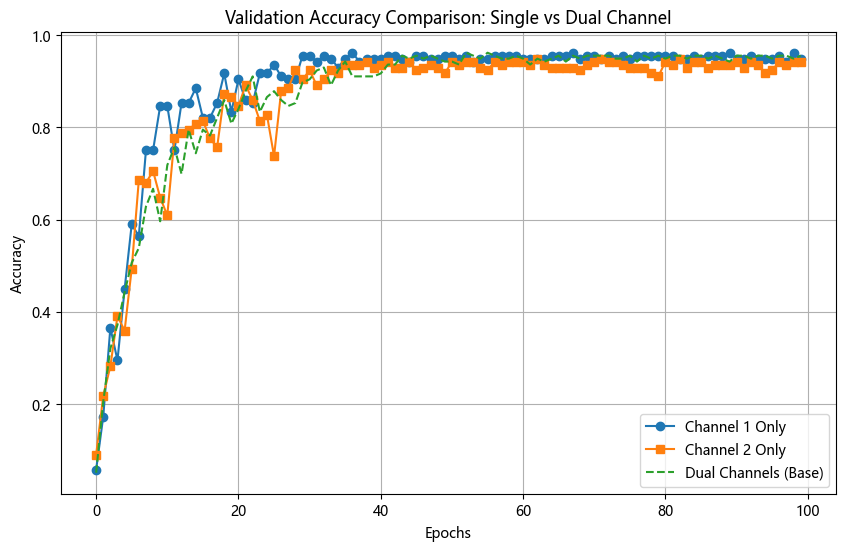

In [24]:
# 绘制对比结果
plt.figure(figsize=(10, 6))
plt.plot(hist_ch1['val_acc'], label='Channel 1 Only', marker='o')
plt.plot(hist_ch2['val_acc'], label='Channel 2 Only', marker='s')
# 如果有双通道的 history (假设在之前的 cell 中叫 history['val_acc']), 可以一起画
if 'history' in locals() and len(history['val_acc']) > 0:
    # 截取相同长度以便对比
    dual_acc = history['val_acc'][:len(hist_ch1['val_acc'])]
    plt.plot(dual_acc, label='Dual Channels (Base)', linestyle='--')

plt.title('Validation Accuracy Comparison: Single vs Dual Channel')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

Device: cuda
>>> Config: Selected Dual Channels (Ch1 + Ch2)
成功加载权重: best_deep_morse_model.pth
使用了原始信号 (Raw Signal)，未进行滤波。
File: AB，E，10.3.csv
Mode: Using Channels ['Ch1', 'Ch2'] for Prediction
Total samples: 3162, Window Size: 300, Stride: 300
Ignored tail segment with length 162 (< 300)


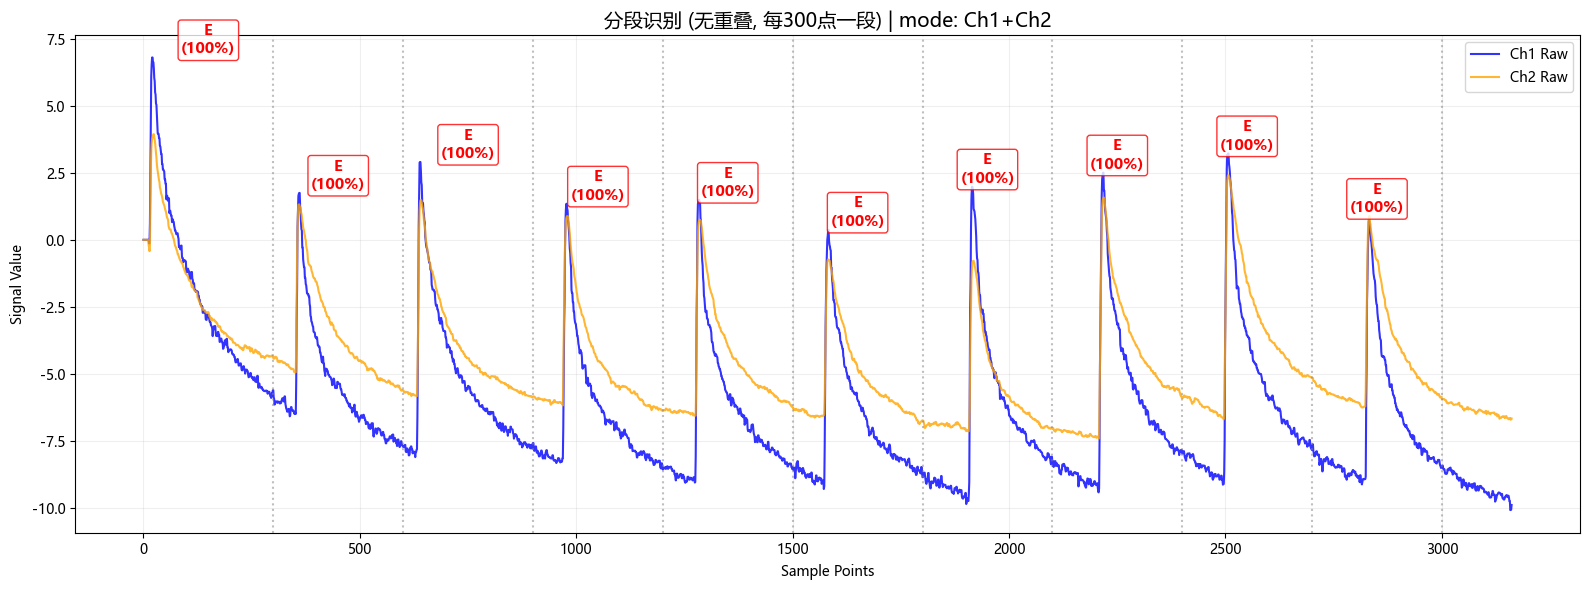


>>> Full Predicted Stream (Ch1+Ch2): E E E E E E E E E E


In [35]:
# 9. 单个文件分段推理与可视化 (Segmented Inference - Raw Signal)
# 完善依赖库导入，确保可以独立运行 
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 显示中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# --- 1. 定义必要的类和函数 (以便独立运行此单元格) ---

def read_sample_csv(file_path):
    """
    读取拆分后的样本 CSV 文件。
    """
    try:
        # 新数据集是标准的 CSV，第一行作为 header
        data = pd.read_csv(file_path)
        
        # 寻找包含 ΔR/R0 的列
        # 注意：拆分脚本保留了原始列名，可能会有 "ΔR/R0 (%)" 和 "ΔR/R0 (%).1"
        delta_cols = [c for c in data.columns if 'ΔR/R0' in str(c)]
        
        if len(delta_cols) >= 2:
            # 取前两个 ΔR/R0 列 (对应 Ch1, Ch2)
            features = data[delta_cols[:2]].copy()
        else:
            # 只有1列或者找不到，回退到按位置取 (2, 4)
            if data.shape[1] > 4:
                features = data.iloc[:, [2, 4]].copy()
            else:
                features = data.select_dtypes(include=[np.number])

        # 转为数值
        features = features.apply(pd.to_numeric, errors='coerce').fillna(0)
        return features.values
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, padding=2):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.downsample = None
            
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        return out

class DeepMorseNet(nn.Module):
    def __init__(self, num_classes=26, input_channels=2):
        super(DeepMorseNet, self).__init__()
        
        # 1. CNN Features Extraction (ResNet-style blocks)
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            ResidualBlock(32, 64),
            nn.MaxPool1d(2),
            
            ResidualBlock(64, 128),
            nn.MaxPool1d(2),
            
            ResidualBlock(128, 256),
            nn.AdaptiveAvgPool1d(40) # 强制压缩到长度40的时间步，减少LSTM计算量
        )
        
        # 2. Bi-LSTM
        self.lstm = nn.LSTM(input_size=256, hidden_size=128, num_layers=2, 
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        # 3. Classifier
        self.fc = nn.Sequential(
            nn.Linear(128*2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x: [Batch, 2, SeqLen]
        features = self.cnn(x) # -> [Batch, 256, 40]
        
        features = features.permute(0, 2, 1) # -> [Batch, 40, 256]
        
        lstm_out, _ = self.lstm(features) # -> [Batch, 40, 256]
        
        # Use last time step output (or max-pooling over time)
        # Using Max Pooling over time captures the most salient features
        context = torch.max(lstm_out, dim=1)[0] # -> [Batch, 256]
        
        out = self.fc(context)
        return out

# --- 2. 推理逻辑 ---

# 指定待识别的文件路径
target_file_path = r"D:\huxi\data\AB，E，10.3.csv"

def predict_segments_and_plot(file_path, model, device, label_encoder, seq_len, stride=None, use_channels=[0]):
    """
    分段读取文件并进行推理和可视化
    use_channels: list of channel indices to use. [0] for Ch1, [1] for Ch2.
    stride: 移动步长，默认为seq_len（无重叠），设置更小值可实现重叠滑动窗口。
    """
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    data = read_sample_csv(file_path) # Returns numpy array [Total_Length, 2]
    
    if data is None or len(data) == 0:
        print("Error reading file or empty data.")
        return

    total_len = len(data)
    print("使用了原始信号 (Raw Signal)，未进行滤波。")
    
    # 设置步长：如果未指定，默认稍微密集一点，例如窗口的 1/3，以便捕捉更多细节
    if stride is None:
        stride_len = seq_len // 3
    else:
        stride_len = stride
    
    channel_names = ["Ch1", "Ch2"]
    selected_names = [channel_names[i] for i in use_channels]
    
    print(f"File: {os.path.basename(file_path)}")
    print(f"Mode: Using Channels {selected_names} for Prediction")
    
    # Check model compatibility
    try:
        model_in_channels = model.cnn[0].in_channels
    except:
        model_in_channels = 2 # default fallback
        
    if model_in_channels != len(use_channels):
        print(f"Warning: Model expects {model_in_channels} channels, but using {len(use_channels)} channels.")
        print("Strategy: Filling unused channels with Zeros (Mean value).")

    print(f"Total samples: {total_len}, Window Size: {seq_len}, Stride: {stride_len}")

    plt.figure(figsize=(16, 6))
    
    # 绘制波形
    time_axis = np.arange(total_len)
    colors = ['blue', 'orange']
    
    for i in use_channels:
        if i < data.shape[1]:
            plt.plot(time_axis, data[:, i], label=f'Ch{i+1} Raw', color=colors[i], alpha=0.8, linewidth=1.5)
    
    predicted_sequence = []
    
    model.eval()
    
    current_start = 0
    seg_count = 0
    
    # 2. 循环处理每个片段
    while current_start < total_len:
        start_idx = current_start
        end_idx = min(start_idx + seq_len, total_len)
        
        # 提取片段
        segment = data[start_idx:end_idx]
        real_len = len(segment)
        
        # 用户要求：不满完整窗口长度（即300点）的片段不预测，直接跳过/结束
        if real_len < seq_len:
            print(f"Ignored tail segment with length {real_len} (< {seq_len})")
            break

        # 预处理：片段内标准化 (Standardization per segment)
        mean = np.mean(segment, axis=0)
        std = np.std(segment, axis=0) + 1e-6
        segment_norm = (segment - mean) / std
        
        # Padding
        segment_valid = segment_norm

        # 构建输入 Tensor
        # 如果模型是单通道 (model_in_channels=1)，我们只取 use_channels 里的那个通道
        if model_in_channels == len(use_channels):
            seg_input = segment_valid[:, use_channels] # [Length, C]
        else:
            # Fallback: 模型通道数与使用通道数不匹配时，进行填充
            seg_input = np.zeros((seq_len, model_in_channels))
            for idx, ch in enumerate(use_channels):
                if ch < model_in_channels:
                    seg_input[:, ch] = segment_valid[:, ch]
        
        if seg_input.ndim == 1: seg_input = seg_input[:, np.newaxis]
        tensor_input = torch.tensor(seg_input, dtype=torch.float32).permute(1, 0).unsqueeze(0).to(device)
        
        # 推理
        with torch.no_grad():
            outputs = model(tensor_input)
            probs = torch.softmax(outputs, dim=1)
            conf, pred_idx = torch.max(probs, 1)
            
        pred_label = label_encoder.inverse_transform(pred_idx.cpu().numpy())[0]
        conf_val = conf.item()
        
        predicted_sequence.append(pred_label)
        
        # 3. 可视化
        # 画分割线
        if end_idx < total_len:
             plt.axvline(x=end_idx, color='gray', linestyle=':', alpha=0.5)
        
        mid_point = (start_idx + end_idx) / 2
        text_y = np.max(segment[:, use_channels]) if len(segment) > 0 and len(use_channels) > 0 else 0
        if isinstance(text_y, np.ndarray): text_y = text_y.max()
        
        # 显示预测结果
        plt.text(mid_point, text_y, f"{pred_label}\n({conf_val:.0%})", 
                 color='red', ha='center', va='bottom', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.8))
                 
        current_start += stride_len
        seg_count += 1

    ch_str = "+".join(selected_names)
    plt.title(f"分段识别 (无重叠, 每300点一段) | mode: {ch_str}", fontsize=14)
    plt.xlabel("Sample Points")
    plt.ylabel("Signal Value")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    full_seq_str = " ".join(predicted_sequence)
    print(f"\n>>> Full Predicted Stream ({ch_str}): {full_seq_str}")

# --- Main Execution ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # === 参数配置区 ===
    # 1. 窗口大小 (Window Size)
    INFERENCE_WINDOW = 300 
    INFERENCE_STRIDE = INFERENCE_WINDOW

    # === 关键：选择使用的通道 ===
    # user_selected_channels = [0]       # 仅使用 Ch1
    # user_selected_channels = [1]       # 仅使用 Ch2
    user_selected_channels = [0,1]    # 使用 Ch1 + Ch2 (双通道)
    
    # 自动根据通道选择匹配的模型路径和输入维度
    if user_selected_channels == [0]:
        model_weights_path = 'best_model_ch1.pth'
        model_input_channels = 1
        print(">>> Config: Selected Channel 1 Only (Single Channel Model)")
    elif user_selected_channels == [1]:
        model_weights_path = 'best_model_ch2.pth'
        model_input_channels = 1
        print(">>> Config: Selected Channel 2 Only (Single Channel Model)")
    elif set(user_selected_channels) == {0, 1}:
        model_weights_path = 'best_deep_morse_model.pth' # 之前训练的双通道基准模型
        model_input_channels = 2
        print(">>> Config: Selected Dual Channels (Ch1 + Ch2)")
    else:
        print("Warning: Unknown channel configuration, defaulting to dual channel.")
        model_weights_path = 'best_deep_morse_model.pth'
        model_input_channels = 2

    if 'DeepMorseNet' in globals():
        num_classes = 26 
        # 初始化对应维度的模型
        model_inference = DeepMorseNet(num_classes=num_classes, input_channels=model_input_channels).to(device)
        
        if os.path.exists(model_weights_path):
            try:
                model_inference.load_state_dict(torch.load(model_weights_path, map_location=device))
                print(f"成功加载权重: {model_weights_path}")
                model_inference.eval()
                
                if 'label_encoder' in globals():
                    le = label_encoder
                else:
                    le = LabelEncoder()
                    le.fit([chr(c) for c in range(ord('A'), ord('Z')+1)])

                predict_segments_and_plot(target_file_path, model_inference, device, le, 
                                          seq_len=INFERENCE_WINDOW, 
                                          stride=INFERENCE_STRIDE,
                                          use_channels=user_selected_channels) 
                
            except Exception as e:
                print(f"Error loading weights: {e}")
                print(f"Tip: 请确保已训练并生成了对应的权重文件: {model_weights_path}")
        else:
            print(f"Weight file not found: {model_weights_path}")
            print(f"Tip: 请先运行上面的实验Cell来生成所需的模型文件.")
    else:
        print("Error: DeepMorseNet definition not found. Please run the cell above.")